# **Import Dependencies**

In [1]:
import os, time, datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# **Konfigurasi Global**

In [2]:
SEED        = 42
BATCH_SIZE  = 32 # Diturunkan ke 32 agar lebih aman untuk memori GPU/RAM
EPOCHS      = 30
IMG_SIZE    = 224 # Diubah ke 224 (ukuran 32x32 terlalu kecil untuk gambar buah asli)
LR_INIT     = 1e-3
DATA_DIR    = "datasetBuah2" # Path ke folder utamamu

tf.random.set_seed(SEED)
np.random.seed(SEED)

# **Load dan Preprocessing Data**

In [3]:
import tensorflow as tf
import numpy as np
from google.colab import drive

# 1. Hubungkan Google Drive
drive.mount('/content/drive')

# ==========================================
# HYPERPARAMETERS & DIREKTORI
# ==========================================
SEED        = 42
IMG_SIZE    = 224

# 2. Arahkan langsung ke sub-folder train dan test
TRAIN_DIR   = "/content/drive/MyDrive/DATASET/dataset_gambar/train"
TEST_DIR    = "/content/drive/MyDrive/DATASET/dataset_gambar/test"
# VALID_DIR = "/content/drive/MyDrive/DATASET/dataset_gambar/valid" # (Gunakan ini jika ingin memakai data validasi)

tf.random.set_seed(SEED)
np.random.seed(SEED)

def load_dataset_to_numpy_split(train_dir, test_dir, img_size, seed):
    print("[INFO] Membaca gambar dari folder train dan test yang sudah terpisah...")

    # 1. Baca folder Train (Gunakan semua isi folder train)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        seed=seed,
        image_size=(img_size, img_size),
        batch_size=32,
        label_mode='categorical'
    )

    # 2. Baca folder Test (Gunakan semua isi folder test)
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        seed=seed,
        image_size=(img_size, img_size),
        batch_size=32,
        label_mode='categorical'
    )

    class_names = train_ds.class_names
    print(f"\n[INFO] Kelas ditemukan: {class_names}")

    # 3. Ekstrak data dari pipeline ke dalam List
    print("[INFO] Mengonversi gambar ke Numpy Arrays (Proses ini butuh beberapa menit)...")
    x_train, y_train_ohe = [], []
    for images, labels in train_ds.unbatch():
        x_train.append(images.numpy())
        y_train_ohe.append(labels.numpy())

    x_test, y_test_ohe = [], []
    for images, labels in test_ds.unbatch():
        x_test.append(images.numpy())
        y_test_ohe.append(labels.numpy())

    # 4. Ubah ke bentuk Numpy Array utuh
    x_train = np.array(x_train)
    y_train_ohe = np.array(y_train_ohe)
    x_test = np.array(x_test)
    y_test_ohe = np.array(y_test_ohe)

    # 5. Normalisasi Pixel ke [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32')  / 255.0

    # 6. Buat raw labels (1D) untuk kebutuhan visualisasi (np.where)
    y_train_raw = np.argmax(y_train_ohe, axis=1)
    y_test_raw = np.argmax(y_test_ohe, axis=1)

    print("\n--- RINGKASAN DATASET ---")
    print(f'Train : {x_train.shape}  labels (OHE): {y_train_ohe.shape}')
    print(f'Test  : {x_test.shape}   labels (OHE): {y_test_ohe.shape}')
    print(f'Pixel range train: [{x_train.min():.2f}, {x_train.max():.2f}]')
    print("-------------------------\n")

    return (x_train, y_train_ohe), (x_test, y_test_ohe), y_train_raw, y_test_raw, class_names

# ==========================================
# EKSEKUSI FUNGSI
# ==========================================
(x_train, y_train_ohe), (x_test, y_test_ohe), y_train_raw, y_test_raw, CLASSES = load_dataset_to_numpy_split(TRAIN_DIR, TEST_DIR, IMG_SIZE, SEED)

NUM_CLASSES = len(CLASSES)
print(f"[INFO] Jumlah Total Kelas: {NUM_CLASSES}")

Mounted at /content/drive
[INFO] Membaca gambar dari folder train dan test yang sudah terpisah...
Found 5199 files belonging to 13 classes.
Found 650 files belonging to 13 classes.

[INFO] Kelas ditemukan: ['Ayam Goreng', 'Burger', 'French Fries', 'Gado-Gado', 'Ikan Goreng', 'Mie Goreng', 'Nasi Goreng', 'Nasi Padang', 'Pizza', 'Rawon', 'Rendang', 'Sate', 'Soto']
[INFO] Mengonversi gambar ke Numpy Arrays (Proses ini butuh beberapa menit)...

--- RINGKASAN DATASET ---
Train : (5199, 224, 224, 3)  labels (OHE): (5199, 13)
Test  : (650, 224, 224, 3)   labels (OHE): (650, 13)
Pixel range train: [0.00, 1.00]
-------------------------

[INFO] Jumlah Total Kelas: 13


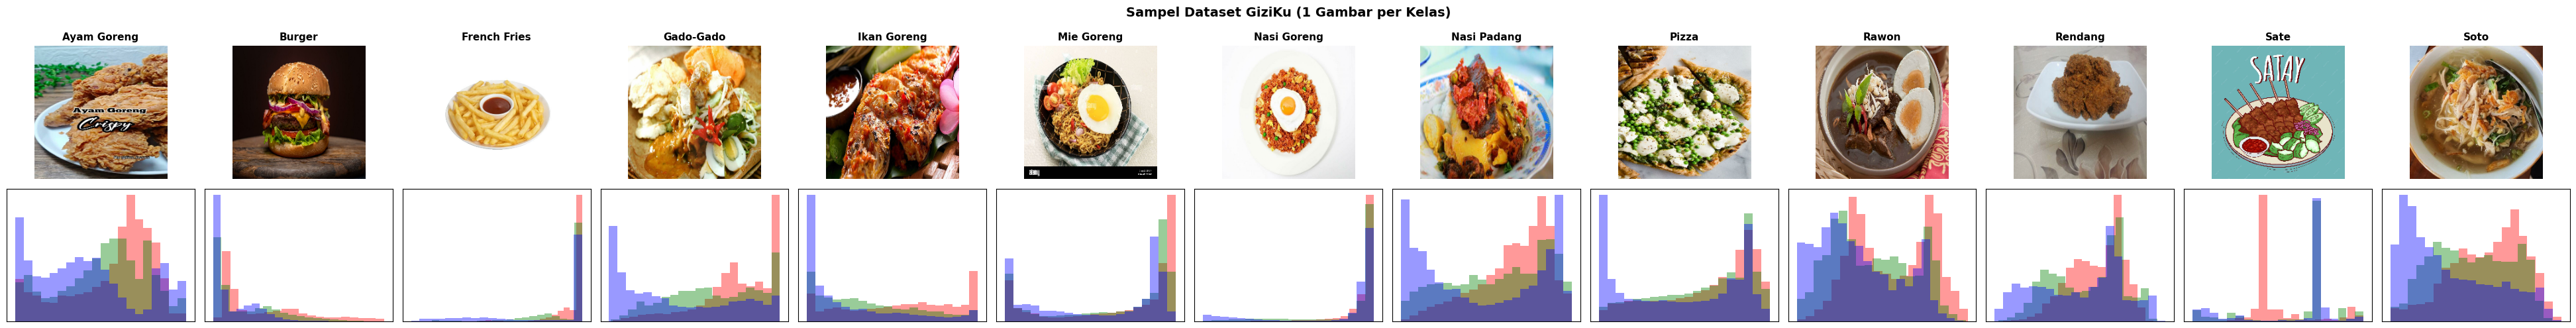

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Pastikan variabel ini sudah ada dari eksekusi fungsi load data:
# x_train, y_train_raw, CLASSES, NUM_CLASSES
num_classes = len(CLASSES)

# Ubah subplots agar menyesuaikan dengan num_classes secara dinamis
fig, axes = plt.subplots(2, num_classes, figsize=(3 * num_classes, 5))
fig.suptitle('Sampel Dataset GiziKu (1 Gambar per Kelas)', fontsize=14, fontweight='bold')

for cls_idx in range(num_classes):
    # 1. MENGAMBIL SAMPEL DARI X_TRAIN
    # Cari index pertama dari array y_train_raw yang cocok dengan kelas saat ini
    try:
        sample_idx = np.where(y_train_raw == cls_idx)[0][0]
        img = x_train[sample_idx]
    except IndexError:
        print(f"[WARNING] Tidak ada gambar ditemukan untuk kelas {CLASSES[cls_idx]}")
        continue

    # Karena dataset kita sudah di-rescale (1./255) di tahap load data,
    # kita hanya memastikan nilainya tidak keluar batas menggunakan clip.
    img_disp = np.clip(img, 0, 1)

    # Menangani kasus khusus jika num_classes hanya 1
    ax_img = axes[0, cls_idx] if num_classes > 1 else axes[0]
    ax_hist = axes[1, cls_idx] if num_classes > 1 else axes[1]

    # Baris 0: Plot Gambar Asli
    ax_img.imshow(img_disp)
    ax_img.set_title(CLASSES[cls_idx], fontsize=11, fontweight='bold')
    ax_img.axis('off')

    # Baris 1: Plot Histogram Distribusi Pixel (RGB)
    for c, color in enumerate(['red', 'green', 'blue']):
        # img[:, :, c] mengambil channel warna spesifik
        ax_hist.hist(img[:, :, c].flatten(), bins=20, color=color, alpha=0.4, density=True)

    ax_hist.set_yticks([])
    ax_hist.set_xticks([])

plt.tight_layout()
plt.show()

In [5]:
def build_tf_datasets(x_train, y_train, x_test, y_test):
    """Buat tf.data pipeline dengan augmentasi on-the-fly."""

    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.15)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        # Random crop: pad 4px lalu crop kembali ke ukuran asli
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 4, IMG_SIZE + 4)
        image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
        return image, label

    train_ds = (tf.data.Dataset
                .from_tensor_slices((x_train, y_train))
                .shuffle(10_000, seed=SEED)
                .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

    test_ds = (tf.data.Dataset
               .from_tensor_slices((x_test, y_test))
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

    return train_ds, test_ds


train_ds, test_ds = build_tf_datasets(x_train, y_train_ohe, x_test, y_test_ohe)

# Cek satu batch
sample_batch = next(iter(train_ds))
print(f'Batch images shape : {sample_batch[0].shape}')
print(f'Batch labels shape : {sample_batch[1].shape}')
print(f'Jumlah batch train  : {len(train_ds)}')
print(f'Jumlah batch test   : {len(test_ds)}')

Batch images shape : (32, 224, 224, 3)
Batch labels shape : (32, 13)
Jumlah batch train  : 163
Jumlah batch test   : 21


# **Custom Layer**

In [6]:
class SqueezeExcitationBlock(layers.Layer):
    """
    SE Block: recalibrates channel-wise feature responses secara adaptif.
    Paper: 'Squeeze-and-Excitation Networks' (Hu et al., 2018)

    Args:
        ratio (int): faktor reduksi bottleneck (default 8)
    """

    def __init__(self, ratio: int = 8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        reduced  = max(1, channels // self.ratio)

        self.gap     = layers.GlobalAveragePooling2D(keepdims=True)
        self.squeeze = layers.Dense(reduced,  activation='relu',    use_bias=False)
        self.excite  = layers.Dense(channels, activation='sigmoid', use_bias=False)
        super().build(input_shape)

    def call(self, x):
        s = self.gap(x)       # Squeeze  → (B, 1, 1, C)
        s = self.squeeze(s)   # Compress → (B, 1, 1, C/r)
        s = self.excite(s)    # Excite   → (B, 1, 1, C)  nilai 0–1
        return x * s          # Scale    → channel attention

    def get_config(self):     # WAJIB untuk save/load model
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


# ── Quick test ───────────────────────────────────────
x_dummy = tf.random.normal([2, 8, 8, 32])   # batch=2, H=8, W=8, C=32
se = SqueezeExcitationBlock(ratio=8, name='se_test')
out = se(x_dummy)
print(f'Input  shape : {x_dummy.shape}')
print(f'Output shape : {out.shape}  (harus sama dengan input)')
print(f'Trainable params: {se.count_params():,}')

Input  shape : (2, 8, 8, 32)
Output shape : (2, 8, 8, 32)  (harus sama dengan input)
Trainable params: 256


In [7]:
class DepthwiseSepConvBlock(layers.Layer):
    """
    Depthwise Separable Convolution + BN + Activation + SE Block opsional.
    ~8x lebih efisien dari Conv2D biasa.

    Args:
        filters    : jumlah output channel
        kernel_size: ukuran kernel (default 3)
        strides    : stride convolution (1=same size, 2=half size)
        use_se     : aktifkan Squeeze-Excitation setelah pointwise
    """

    def __init__(self, filters: int, kernel_size: int = 3,
                 strides: int = 1, use_se: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.kernel_size = filters, kernel_size
        self.strides, self.use_se = strides, use_se

    def build(self, input_shape):
        # Depthwise: satu filter per channel (spatial filtering)
        self.dw_conv = layers.DepthwiseConv2D(
            self.kernel_size, strides=self.strides, padding='same', use_bias=False)
        self.dw_bn   = layers.BatchNormalization()
        self.dw_act  = layers.Activation('relu6')

        # Pointwise: 1×1 conv untuk mix antar channel
        self.pw_conv = layers.Conv2D(self.filters, 1, use_bias=False)
        self.pw_bn   = layers.BatchNormalization()
        self.pw_act  = layers.Activation('relu6')

        # SE Block opsional
        self.se_block = SqueezeExcitationBlock() if self.use_se else None
        super().build(input_shape)

    def call(self, x, training=False):
        # Depthwise stage
        x = self.dw_act(self.dw_bn(self.dw_conv(x), training=training))
        # Pointwise stage
        x = self.pw_act(self.pw_bn(self.pw_conv(x), training=training))
        # SE attention
        if self.se_block is not None:
            x = self.se_block(x)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'filters': self.filters, 'kernel_size': self.kernel_size,
                    'strides': self.strides, 'use_se': self.use_se})
        return cfg


# ── Quick test ───────────────────────────────────────
x_dummy = tf.random.normal([2, 16, 16, 32])
ds_conv = DepthwiseSepConvBlock(filters=64, strides=2, use_se=True)
out = ds_conv(x_dummy, training=False)
print(f'Input  : {x_dummy.shape}')
print(f'Output : {out.shape}  (stride=2 → spatial /2, channel ×2)')

# Perbandingan parameter
conv2d_params = 3*3*32*64
ds_params     = ds_conv.count_params()
print(f'\nParameter Conv2D biasa  : {conv2d_params:,}')
print(f'Parameter DepthwiseSep  : {ds_params:,}  ({conv2d_params/ds_params:.1f}x lebih sedikit)')

Input  : (2, 16, 16, 32)
Output : (2, 8, 8, 64)  (stride=2 → spatial /2, channel ×2)

Parameter Conv2D biasa  : 18,432
Parameter DepthwiseSep  : 3,744  (4.9x lebih sedikit)


In [8]:
class StochasticDepth(layers.Layer):
    """
    Stochastic Depth: drop seluruh residual branch secara acak saat training.
    Paper: 'Deep Networks with Stochastic Depth' (Huang et al., 2016)

    Args:
        drop_prob (float): probabilitas drop path [0, 1)
    """

    def __init__(self, drop_prob: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=False):
        # Saat inference atau drop_prob=0: tidak ada perubahan
        if not training or self.drop_prob == 0.0:
            return x

        keep_prob  = 1.0 - self.drop_prob
        batch_size = tf.shape(x)[0]

        # Random mask shape (B, 1, 1, 1) → di-broadcast ke seluruh spatial+channel
        random_tensor = tf.cast(
            tf.random.uniform([batch_size, 1, 1, 1]) < keep_prob, x.dtype)

        # Scale agar expected value tetap sama
        return (x / keep_prob) * random_tensor

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'drop_prob': self.drop_prob})
        return cfg


# ── Demo perbedaan training vs inference ─────────────
x_dummy = tf.ones([4, 8, 8, 16])  # semua nilai = 1
sd = StochasticDepth(drop_prob=0.5)

print('=== Inference mode (training=False) ===')
out_inf = sd(x_dummy, training=False)
print(f'  Semua output = 1.0 : {tf.reduce_all(out_inf == 1.0).numpy()}')

print('\n=== Training mode (drop_prob=0.5), run 5x ===')
for i in range(5):
    out_tr = sd(x_dummy, training=True)
    # Cek apakah batch item pertama di-drop
    dropped = float(out_tr[0, 0, 0, 0]) == 0.0
    scale   = float(out_tr[0, 0, 0, 0])
    print(f'  Run {i+1}: item[0] = {scale:.2f}  →  {"DROPPED" if dropped else "KEPT (scaled 2x)"}')

=== Inference mode (training=False) ===
  Semua output = 1.0 : True

=== Training mode (drop_prob=0.5), run 5x ===
  Run 1: item[0] = 0.00  →  DROPPED
  Run 2: item[0] = 0.00  →  DROPPED
  Run 3: item[0] = 0.00  →  DROPPED
  Run 4: item[0] = 0.00  →  DROPPED
  Run 5: item[0] = 2.00  →  KEPT (scaled 2x)


# **Custom Model**

## Functional API

In [9]:
def build_functional_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    dropout_rate=0.4,
) -> Model:
    """
    MiniSENet via Functional API.
    Stem → 3 Stage (DepthwiseSepConv + SE + Residual) → GAP → Classifier
    """
    inputs = keras.Input(shape=input_shape, name='input_image')

    # ── Stem ─────────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name='stem_conv')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('relu6', name='stem_act')(x)

    # ── Stage 1 · 64 ch · stride 1 ───────────────────────
    residual = layers.Conv2D(64, 1, padding='same', use_bias=False, name='s1_proj')(x)
    x = DepthwiseSepConvBlock(64, name='s1_dsconv')(x)
    x = StochasticDepth(drop_prob=0.05, name='s1_sd')(x)
    x = layers.Add(name='s1_add')([x, residual])

    # ── Stage 2 · 128 ch · stride 2 ──────────────────────
    residual = layers.Conv2D(128, 1, strides=2, padding='same', use_bias=False, name='s2_proj')(x)
    x = DepthwiseSepConvBlock(128, strides=2, name='s2_dsconv')(x)
    x = StochasticDepth(drop_prob=0.10, name='s2_sd')(x)
    x = layers.Add(name='s2_add')([x, residual])

    # ── Stage 3 · 256 ch · stride 2 ──────────────────────
    residual = layers.Conv2D(256, 1, strides=2, padding='same', use_bias=False, name='s3_proj')(x)
    x = DepthwiseSepConvBlock(256, strides=2, name='s3_dsconv')(x)
    x = StochasticDepth(drop_prob=0.15, name='s3_sd')(x)
    x = layers.Add(name='s3_add')([x, residual])

    # ── Head ─────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(dropout_rate, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs, outputs, name='MiniSENet_Functional')


model_functional = build_functional_model()
model_functional.summary(line_length=80)

Model: "MiniSENet_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_image           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_conv (Conv2D)    │ (None, 224, 224,  │         864 │ input_image[0][0]  │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_bn               │ (None, 224, 224,  │         128 │ stem_conv[0][0]    │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_act (Activation) │ (None, 224, 224,  │           0 │ stem_bn[0][0]      │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s1_dsconv             │ (None, 224, 224,  │       3,744 │ stem_act[0][0]     │
│ (DepthwiseSepConvBlo… │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s1_sd                 │ (None, 224, 224,  │           0 │ s1_dsconv[0][0]    │
│ (StochasticDepth)     │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s1_proj (Conv2D)      │ (None, 224, 224,  │       2,048 │ stem_act[0][0]     │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s1_add (Add)          │ (None, 224, 224,  │           0 │ s1_sd[0][0],       │
│                       │ 64)               │             │ s1_proj[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s2_dsconv             │ (None, 112, 112,  │      13,632 │ s1_add[0][0]       │
│ (DepthwiseSepConvBlo… │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s2_sd                 │ (None, 112, 112,  │           0 │ s2_dsconv[0][0]    │
│ (StochasticDepth)     │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s2_proj (Conv2D)      │ (None, 112, 112,  │       8,192 │ s1_add[0][0]       │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s2_add (Add)          │ (None, 112, 112,  │           0 │ s2_sd[0][0],       │
│                       │ 128)              │             │ s2_proj[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s3_dsconv             │ (None, 56, 56,    │      51,840 │ s2_add[0][0]       │
│ (DepthwiseSepConvBlo… │ 256)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s3_sd                 │ (None, 56, 56,    │           0 │ s3_dsconv[0][0]    │
│ (StochasticDepth)     │ 256)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s3_proj (Conv2D)      │ (None, 56, 56,    │      32,768 │ s2_add[0][0]       │
│                       │ 256)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ s3_add (Add)          │ (None, 56, 56,    │           0 │ s3_sd[0][0],       │
│                       │ 256) 

 Total params: 116,557 (455.30 KB)

 Trainable params: 115,149 (449.80 KB)

 Non-trainable params: 1,408 (5.50 KB)

## Model Subclassing

In [10]:
class ResidualBlock(layers.Layer):
    """Residual block: dua DepthwiseSepConv + StochasticDepth + projection shortcut."""

    def __init__(self, filters: int, strides: int = 1,
                 drop_prob: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.strides, self.drop_prob = filters, strides, drop_prob

    def build(self, input_shape):
        self.dsconv1 = DepthwiseSepConvBlock(self.filters, strides=self.strides)
        self.dsconv2 = DepthwiseSepConvBlock(self.filters, use_se=True)
        self.sd      = StochasticDepth(self.drop_prob)

        # Projection shortcut jika dimensi berubah
        in_ch = input_shape[-1]
        if in_ch != self.filters or self.strides != 1:
            self.proj    = layers.Conv2D(self.filters, 1, strides=self.strides,
                                         padding='same', use_bias=False)
            self.proj_bn = layers.BatchNormalization()
        else:
            self.proj = None
        super().build(input_shape)

    def call(self, x, training=False):
        shortcut = x
        if self.proj is not None:
            shortcut = self.proj_bn(self.proj(shortcut), training=training)

        x = self.dsconv1(x, training=training)
        x = self.dsconv2(x, training=training)
        x = self.sd(x, training=training)
        return tf.nn.relu(x + shortcut)   # residual connection

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'filters': self.filters, 'strides': self.strides,
                    'drop_prob': self.drop_prob})
        return cfg


class MiniResNet(Model):
    """
    MiniResNet via Subclassing API.

    Args:
        num_classes  : jumlah kelas output
        base_filters : lebar jaringan (jumlah filter stage pertama)
        dropout_rate : dropout sebelum classifier
    """

    def __init__(self, num_classes=NUM_CLASSES,
                 base_filters=64, dropout_rate=0.4, **kwargs):
        super().__init__(**kwargs)
        self.num_classes  = num_classes
        self.base_filters = base_filters
        self.dropout_rate = dropout_rate

        # Stem
        self.stem_conv = layers.Conv2D(base_filters, 3, padding='same',
                                       use_bias=False, name='stem_conv')
        self.stem_bn   = layers.BatchNormalization(name='stem_bn')
        self.stem_act  = layers.Activation('relu6', name='stem_act')

        # Stages: channels bertambah, spatial berkurang
        f = base_filters
        self.stage1 = ResidualBlock(f,     strides=1, drop_prob=0.05, name='stage1')
        self.stage2 = ResidualBlock(f * 2, strides=2, drop_prob=0.10, name='stage2')
        self.stage3 = ResidualBlock(f * 4, strides=2, drop_prob=0.15, name='stage3')
        self.stage4 = ResidualBlock(f * 4, strides=1, drop_prob=0.20, name='stage4')

        # Head
        self.gap     = layers.GlobalAveragePooling2D(name='gap')
        self.dropout = layers.Dropout(dropout_rate, name='dropout')
        self.clf     = layers.Dense(num_classes, activation='softmax', name='predictions')

    def call(self, x, training=False):
        x = self.stem_act(self.stem_bn(self.stem_conv(x), training=training))
        x = self.stage1(x, training=training)
        x = self.stage2(x, training=training)
        x = self.stage3(x, training=training)
        x = self.stage4(x, training=training)
        return self.clf(self.dropout(self.gap(x), training=training))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes': self.num_classes,
                    'base_filters': self.base_filters,
                    'dropout_rate': self.dropout_rate})
        return cfg

    @classmethod
    def from_config(cls, config): return cls(**config)


model_subclass = MiniResNet(name='MiniResNet_Subclassing')
model_subclass.build((None, IMG_SIZE, IMG_SIZE, 3))
model_subclass.summary(line_length=80)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'MiniResNet_Subclassing', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "MiniResNet_Subclassing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stem_conv (Conv2D)                │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)      │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_act (Activation)             │ ?                        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stage1 (ResidualBlock)            │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stage2 (ResidualBlock)            │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stage3 (ResidualBlock)            │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stage4 (ResidualBlock)            │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ ?                        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ ?                        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ ?                        │   0 (unbuilt) │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Comparing Kedua Custom Model

In [11]:
func_params = model_functional.count_params()
sub_params  = model_subclass.count_params()

print('┌─────────────────────────────────────────────┐')
print('│          Perbandingan Parameter Model        │')
print('├──────────────────────┬──────────┬────────────┤')
print('│ Model                │ API      │ Parameters │')
print('├──────────────────────┼──────────┼────────────┤')
print(f'│ MiniSENet            │ Functional│ {func_params:>9,} │')
print(f'│ MiniResNet           │ Subclass │ {sub_params:>9,} │')
print('└──────────────────────┴──────────┴────────────┘')

# Pilih model yang akan di-train
# Ganti ke model_subclass jika ingin train MiniResNet
model = model_functional
print(f'\n>>> Model yang dipilih untuk training: {model.name}')

┌─────────────────────────────────────────────┐
│          Perbandingan Parameter Model        │
├──────────────────────┬──────────┬────────────┤
│ Model                │ API      │ Parameters │
├──────────────────────┼──────────┼────────────┤
│ MiniSENet            │ Functional│   116,557 │
│ MiniResNet           │ Subclass │         0 │
└──────────────────────┴──────────┴────────────┘

>>> Model yang dipilih untuk training: MiniSENet_Functional


# **Custom Loss**

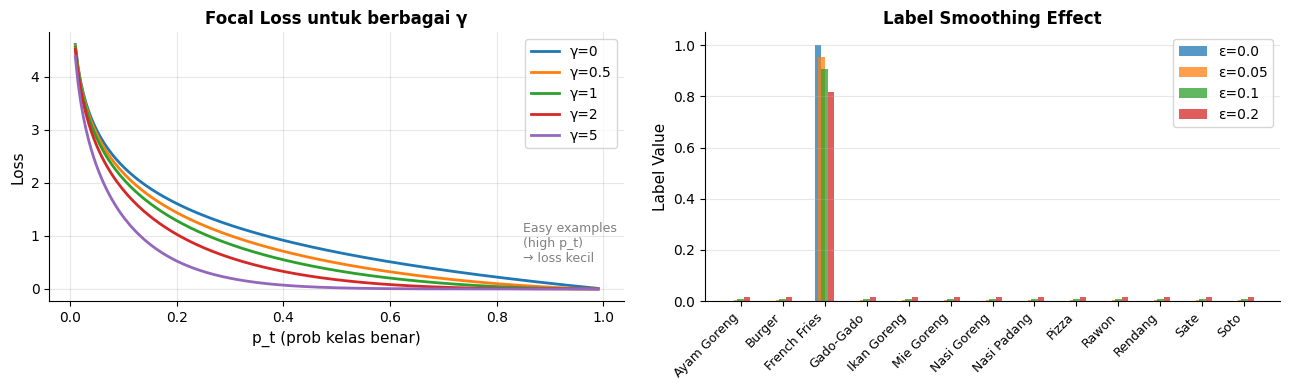

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Asumsi CLASSES dan NUM_CLASSES sudah ada dari kode sebelumnya
# NUM_CLASSES = 6
# CLASSES = ['apple', 'banana', 'grapes', 'mango', 'orange', 'strawberry']

class LabelSmoothingFocalLoss(keras.losses.Loss):
    # ... (Kode class ini sama persis dengan yang kamu miliki) ...
    def __init__(self, smoothing: float = 0.1, gamma: float = 2.0,
                 alpha: float = 0.25, name: str = 'label_smooth_focal', **kwargs):
        super().__init__(name=name, **kwargs)
        self.smoothing = smoothing
        self.gamma     = gamma
        self.alpha     = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        K = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_smooth = y_true * (1.0 - self.smoothing) + (self.smoothing / K)
        p_t = tf.reduce_sum(y_smooth * y_pred, axis=-1, keepdims=True)
        focal_weight = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        ce = -tf.reduce_sum(y_smooth * tf.math.log(y_pred), axis=-1, keepdims=True)
        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'smoothing': self.smoothing, 'gamma': self.gamma, 'alpha': self.alpha})
        return cfg

class MixupCrossEntropy(keras.losses.Loss):
    # ... (Kode class ini sama persis dengan yang kamu miliki) ...
    def __init__(self, label_smoothing: float = 0.05, name: str = 'mixup_crossentropy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        K = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true = y_true * (1.0 - self.label_smoothing) + self.label_smoothing / K
        return -tf.reduce_mean(tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'label_smoothing': self.label_smoothing})
        return cfg


# ── Visualisasi efek gamma pada Focal Loss ────────────
p_range = np.linspace(0.01, 0.99, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for gamma in [0, 0.5, 1, 2, 5]:
    fl = -((1 - p_range) ** gamma) * np.log(p_range)
    ax1.plot(p_range, fl, label=f'γ={gamma}', linewidth=2)

ax1.set_xlabel('p_t (prob kelas benar)', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Focal Loss untuk berbagai γ', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
ax1.annotate('Easy examples\n(high p_t)\n→ loss kecil', xy=(0.85, 0.5),
             fontsize=9, color='gray')

# ── PERBAIKAN: Label smoothing effect ─────────────────
# Menggunakan NUM_CLASSES secara dinamis, bukan fix 10
K_dinamis = NUM_CLASSES

# Membuat array y_hard dinamis (misal, kelas index ke-2 yang benar)
y_hard = np.zeros(K_dinamis)
if K_dinamis > 2:
    y_hard[2] = 1 # Anggap kelas ketiga yang benar
else:
    y_hard[0] = 1

for eps in [0.0, 0.05, 0.1, 0.2]:
    y_smooth = y_hard * (1 - eps) + eps / K_dinamis

    # Penyesuaian jarak bar chart agar tidak terlalu menumpuk
    x_pos = np.arange(K_dinamis) + (eps * 1.5)

    ax2.bar(x_pos, y_smooth, width=0.15, label=f'ε={eps}', alpha=0.75)

# Pastikan jumlah xticks sama dengan jumlah CLASSES
ax2.set_xticks(np.arange(K_dinamis) + 0.15)
ax2.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
ax2.set_title('Label Smoothing Effect', fontsize=12, fontweight='bold')
ax2.set_ylabel('Label Value', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# **Custom Callback**

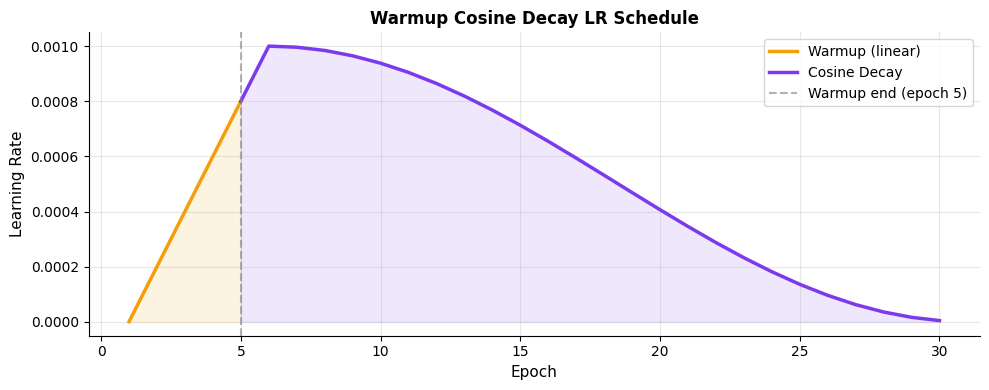

In [13]:
class WarmupCosineDecayScheduler(keras.callbacks.Callback):
    """
    Learning Rate: Linear Warmup → Cosine Decay.

    Args:
        max_lr        : LR puncak setelah warmup
        min_lr        : LR minimum di akhir decay
        warmup_epochs : epoch untuk fase warmup linear
        total_epochs  : total epoch training
        verbose       : cetak LR setiap epoch
    """

    def __init__(self, max_lr, min_lr=1e-6, warmup_epochs=5,
                 total_epochs=EPOCHS, verbose=True):
        super().__init__()
        self.max_lr        = max_lr
        self.min_lr        = min_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.verbose       = verbose
        self.lr_history    = []

    def _compute_lr(self, epoch):
        if epoch < self.warmup_epochs:
            # Linear warmup
            return self.min_lr + (self.max_lr - self.min_lr) * (epoch / self.warmup_epochs)
        else:
            # Cosine decay
            progress = (epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            return self.min_lr + (self.max_lr - self.min_lr) * 0.5 * (1.0 + np.cos(np.pi * progress))

    def on_epoch_begin(self, epoch, logs=None):
        lr = self._compute_lr(epoch)
        # Kompatibel Keras 2 & 3
        opt = self.model.optimizer
        if hasattr(opt.learning_rate, 'assign'):
            opt.learning_rate.assign(lr)
        else:
            opt.learning_rate = lr
        self.lr_history.append(lr)
        if self.verbose:
            phase = 'WARMUP' if epoch < self.warmup_epochs else 'COSINE'
            print(f'  [LRScheduler] Epoch {epoch+1:3d} | {phase:6s} | LR: {lr:.2e}')


# ── Preview jadwal LR ─────────────────────────────────
scheduler_preview = WarmupCosineDecayScheduler(
    max_lr=1e-3, min_lr=1e-6, warmup_epochs=5, total_epochs=30, verbose=False)
lr_preview = [scheduler_preview._compute_lr(e) for e in range(30)]

fig, ax = plt.subplots(figsize=(10, 4))
epochs_range = range(1, 31)
warmup_lr = [lr for i, lr in enumerate(lr_preview) if i < 5]
decay_lr  = [lr for i, lr in enumerate(lr_preview) if i >= 5]

ax.plot(range(1, 6),  warmup_lr, color='#F59E0B', linewidth=2.5, label='Warmup (linear)')
ax.plot(range(5, 31), [lr_preview[4]] + decay_lr, color='#7C3AED',
        linewidth=2.5, label='Cosine Decay')
ax.fill_between(range(1, 6),  warmup_lr, alpha=0.12, color='#F59E0B')
ax.fill_between(range(5, 31), [lr_preview[4]] + decay_lr, alpha=0.12, color='#7C3AED')

ax.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='Warmup end (epoch 5)')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('Warmup Cosine Decay LR Schedule', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

In [14]:
class TrainingDashboard(keras.callbacks.Callback):
    """
    Dashboard training komprehensif: ASCII progress · overfitting detection ·
    best model saving · early stopping · periodic checkpoint.

    Args:
        save_path   : direktori penyimpanan checkpoint
        patience    : epoch tanpa perbaikan sebelum early stop
        min_delta   : threshold minimal improvement
        monitor     : metrik yang dipantau
        early_stop  : aktifkan early stopping
    """

    def __init__(self, save_path='checkpoints', patience=8, min_delta=1e-4,
                 monitor='val_accuracy', early_stop=True):
        super().__init__()
        self.save_path  = save_path
        self.patience   = patience
        self.min_delta  = min_delta
        self.monitor    = monitor
        self.early_stop = early_stop

        self.best_value = -np.inf if 'accuracy' in monitor else np.inf
        self.wait       = 0
        self.best_epoch = 0
        self.history    = defaultdict(list)
        self.start_time = None
        os.makedirs(save_path, exist_ok=True)

    def _is_better(self, current):
        if 'accuracy' in self.monitor:
            return current > self.best_value + self.min_delta
        return current < self.best_value - self.min_delta

    def _bar(self, value, max_val=1.0, width=20):
        n = int(round(value / max_val * width))
        return f"[{'█'*n}{'░'*(width-n)}]"

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print('\n' + '='*65)
        print(f'  TRAINING STARTED  |  Model: {self.model.name}')
        print(f'  Monitor: {self.monitor}  |  Patience: {self.patience}')
        print('='*65)

    def on_epoch_end(self, epoch, logs=None):
        logs    = logs or {}
        for k, v in logs.items(): self.history[k].append(v)

        tr_acc   = logs.get('accuracy',     0.0)
        val_acc  = logs.get('val_accuracy', 0.0)
        tr_loss  = logs.get('loss',         0.0)
        val_loss = logs.get('val_loss',     0.0)
        current  = logs.get(self.monitor,   0.0)

        # ASCII Dashboard
        elapsed = time.time() - self.start_time
        print(f'\n  Epoch {epoch+1:3d}  [{elapsed/60:.1f} min]')
        print(f'  Train  loss:{tr_loss:.4f}  acc:{tr_acc:.4f} {self._bar(tr_acc)}')
        print(f'  Val    loss:{val_loss:.4f}  acc:{val_acc:.4f} {self._bar(val_acc)}')

        # Overfitting detection
        gap = tr_acc - val_acc
        if gap > 0.10:   status = f'⚠  OVERFIT   (gap={gap:.3f})'
        elif gap < -0.02: status = f'?  UNDERFIT  (gap={gap:.3f})'
        else:             status = f'✓  HEALTHY   (gap={gap:.3f})'
        print(f'  Status : {status}')

        # Best model & early stop
        if self._is_better(current):
            self.best_value = current
            self.best_epoch = epoch + 1
            self.wait = 0
            best_path = os.path.join(self.save_path, 'best_model.weights.h5')
            self.model.save_weights(best_path)
            print(f'  [SAVED] → {best_path}  ({self.monitor}={current:.4f})')
        else:
            self.wait += 1
            print(f'  [EarlyStop] {self.wait}/{self.patience} epoch tanpa perbaikan')
            if self.early_stop and self.wait >= self.patience:
                print(f'\n  [EARLY STOP] Best: {self.monitor}={self.best_value:.4f} @ epoch {self.best_epoch}')
                self.model.stop_training = True

        # Checkpoint periodik
        if (epoch + 1) % 10 == 0:
            ckpt = os.path.join(self.save_path, f'ckpt_epoch{epoch+1:03d}.weights.h5')
            self.model.save_weights(ckpt)
            print(f'  [CHECKPOINT] → {ckpt}')

    def on_train_end(self, logs=None):
        total = time.time() - self.start_time
        print('\n' + '='*65)
        print(f'  SELESAI  |  Durasi: {total/60:.1f} min')
        print(f'  Best Epoch: {self.best_epoch}  |  Best {self.monitor}: {self.best_value:.4f}')
        print('='*65)


print('TrainingDashboard didefinisikan ✓')

TrainingDashboard didefinisikan ✓


In [15]:
class GradientMonitor(keras.callbacks.Callback):
    """
    Pantau norma gradient untuk deteksi vanishing/exploding gradients.

    Args:
        sample_batch : satu batch data (x, y) untuk komputasi gradient
        log_freq     : catat setiap berapa epoch
    """

    def __init__(self, sample_batch, log_freq: int = 5):
        super().__init__()
        self.sample_x, self.sample_y = sample_batch
        self.log_freq     = log_freq
        self.grad_history = []   # untuk analisis post-training

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.log_freq != 0:
            return

        # Hitung gradient pada sample batch
        with tf.GradientTape() as tape:
            preds = self.model(self.sample_x, training=True)
            loss  = self.model.compiled_loss(self.sample_y, preds)

        grads = tape.gradient(loss, self.model.trainable_variables)

        norms = {
            var.name: float(tf.norm(g).numpy())
            for var, g in zip(self.model.trainable_variables, grads)
            if g is not None
        }
        self.grad_history.append({'epoch': epoch + 1, 'norms': norms})

        all_norms = list(norms.values())
        max_norm  = max(all_norms)
        min_norm  = min(all_norms)
        mean_norm = np.mean(all_norms)

        diag = '✓ OK'
        if max_norm  > 100: diag = '⚠ EXPLODING GRADIENT'
        if min_norm < 1e-7: diag = '⚠ VANISHING GRADIENT'

        print(f'  [GradMonitor] Epoch {epoch+1} | '
              f'max={max_norm:.4f}  min={min_norm:.2e}  mean={mean_norm:.4f}  {diag}')


print('GradientMonitor didefinisikan ✓')

GradientMonitor didefinisikan ✓


# **Compile Model**

In [16]:
# ── Inisialisasi optimizer ───────────────────────────
optimizer = keras.optimizers.AdamW(
    learning_rate = LR_INIT,
    weight_decay  = 1e-4,      # L2 regularization bawaan AdamW
    clipnorm      = 1.0,       # gradient clipping untuk stabilitas
)

# ── Loss function custom ────────────────────────────
loss_fn = LabelSmoothingFocalLoss(
    smoothing = 0.1,    # epsilon label smoothing
    gamma     = 2.0,    # focusing parameter
    alpha     = 0.25,   # weighting factor
)

# ── Compile ──────────────────────────────────────────
model.compile(
    optimizer = optimizer,
    loss      = loss_fn,
    metrics   = [
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'),
    ]
)

print(f'Model     : {model.name}')
print(f'Optimizer : {optimizer.__class__.__name__}  (lr={LR_INIT}, wd=1e-4, clipnorm=1.0)')
print(f'Loss      : {loss_fn.name}  (smoothing=0.1, gamma=2.0)')
print(f'Metrics   : accuracy, top3_accuracy')

Model     : MiniSENet_Functional
Optimizer : AdamW  (lr=0.001, wd=1e-4, clipnorm=1.0)
Loss      : label_smooth_focal  (smoothing=0.1, gamma=2.0)
Metrics   : accuracy, top3_accuracy


# **Setup Callback**

In [17]:
# Ambil satu sample batch untuk GradientMonitor
sample_batch_for_grad = next(iter(train_ds.take(1)))

# ── 1. Warmup Cosine Decay LR Scheduler ─────────────
lr_scheduler = WarmupCosineDecayScheduler(
    max_lr        = LR_INIT,
    min_lr        = 1e-6,
    warmup_epochs = 5,
    total_epochs  = EPOCHS,
    verbose       = True,
)

# ── 2. Training Dashboard ────────────────────────────
dashboard = TrainingDashboard(
    save_path  = 'checkpoints',
    patience   = 8,
    monitor    = 'val_accuracy',
    early_stop = True,
)

# ── 3. Gradient Monitor ──────────────────────────────
grad_monitor = GradientMonitor(
    sample_batch = sample_batch_for_grad,
    log_freq     = 5,
)

# ── 4. TensorBoard (built-in) ────────────────────────
log_dir = f"logs/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir        = log_dir,
    histogram_freq = 1,
    write_images   = False,
)

# ── Gabungkan semua ──────────────────────────────────
all_callbacks = [lr_scheduler, dashboard, grad_monitor, tensorboard_cb]

print(f'Callbacks yang aktif ({len(all_callbacks)} callback):')
for i, cb in enumerate(all_callbacks, 1):
    print(f'  {i}. {cb.__class__.__name__}')
print(f'\nTensorBoard log dir: {log_dir}')
print('Jalankan: tensorboard --logdir=logs/')

Callbacks yang aktif (4 callback):
  1. WarmupCosineDecayScheduler
  2. TrainingDashboard
  3. GradientMonitor
  4. TensorBoard

TensorBoard log dir: logs/20260601-090135
Jalankan: tensorboard --logdir=logs/


# **Training**

In [18]:
print('Memulai training...')
print(f'Model      : {model.name}')
print(f'Epochs     : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Steps/epoch: {len(train_ds)}')
print()

history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = test_ds,
    callbacks       = all_callbacks,
    verbose         = 0,   # output dihandle TrainingDashboard
)

Memulai training...
Model      : MiniSENet_Functional
Epochs     : 30
Batch size : 32
Steps/epoch: 163


  TRAINING STARTED  |  Model: MiniSENet_Functional
  Monitor: val_accuracy  |  Patience: 8
  [LRScheduler] Epoch   1 | WARMUP | LR: 1.00e-06

  Epoch   1  [1.8 min]
  Train  loss:0.6093  acc:0.0706 [█░░░░░░░░░░░░░░░░░░░]
  Val    loss:0.5501  acc:0.0769 [██░░░░░░░░░░░░░░░░░░]
  Status : ✓  HEALTHY   (gap=-0.006)
  [SAVED] → checkpoints/best_model.weights.h5  (val_accuracy=0.0769)
  [LRScheduler] Epoch   2 | WARMUP | LR: 2.01e-04

  Epoch   2  [2.4 min]
  Train  loss:0.5315  acc:0.1373 [███░░░░░░░░░░░░░░░░░]
  Val    loss:0.5317  acc:0.1277 [███░░░░░░░░░░░░░░░░░]
  Status : ✓  HEALTHY   (gap=0.010)
  [SAVED] → checkpoints/best_model.weights.h5  (val_accuracy=0.1277)
  [LRScheduler] Epoch   3 | WARMUP | LR: 4.01e-04

  Epoch   3  [2.9 min]
  Train  loss:0.4743  acc:0.2154 [████░░░░░░░░░░░░░░░░]
  Val    loss:0.4784  acc:0.2462 [█████░░░░░░░░░░░░░░░]
  Status : ?  UNDERFIT  (gap=-0.031

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


  [GradMonitor] Epoch 5 | max=0.2576  min=1.90e-02  mean=0.0852  ✓ OK
  [LRScheduler] Epoch   6 | COSINE | LR: 1.00e-03

  Epoch   6  [4.8 min]
  Train  loss:0.3853  acc:0.3603 [███████░░░░░░░░░░░░░]
  Val    loss:0.3824  acc:0.3569 [███████░░░░░░░░░░░░░]
  Status : ✓  HEALTHY   (gap=0.003)
  [SAVED] → checkpoints/best_model.weights.h5  (val_accuracy=0.3569)
  [LRScheduler] Epoch   7 | COSINE | LR: 9.96e-04

  Epoch   7  [5.3 min]
  Train  loss:0.3563  acc:0.4082 [████████░░░░░░░░░░░░]
  Val    loss:0.4098  acc:0.3431 [███████░░░░░░░░░░░░░]
  Status : ✓  HEALTHY   (gap=0.065)
  [EarlyStop] 1/8 epoch tanpa perbaikan
  [LRScheduler] Epoch   8 | COSINE | LR: 9.84e-04

  Epoch   8  [5.9 min]
  Train  loss:0.3408  acc:0.4322 [█████████░░░░░░░░░░░]
  Val    loss:0.5748  acc:0.2369 [█████░░░░░░░░░░░░░░░]
  Status : ⚠  OVERFIT   (gap=0.195)
  [EarlyStop] 2/8 epoch tanpa perbaikan
  [LRScheduler] Epoch   9 | COSINE | LR: 9.65e-04

  Epoch   9  [6.5 min]
  Train  loss:0.3275  acc:0.4510 [███████

# **Visualisasi Hasil Training**

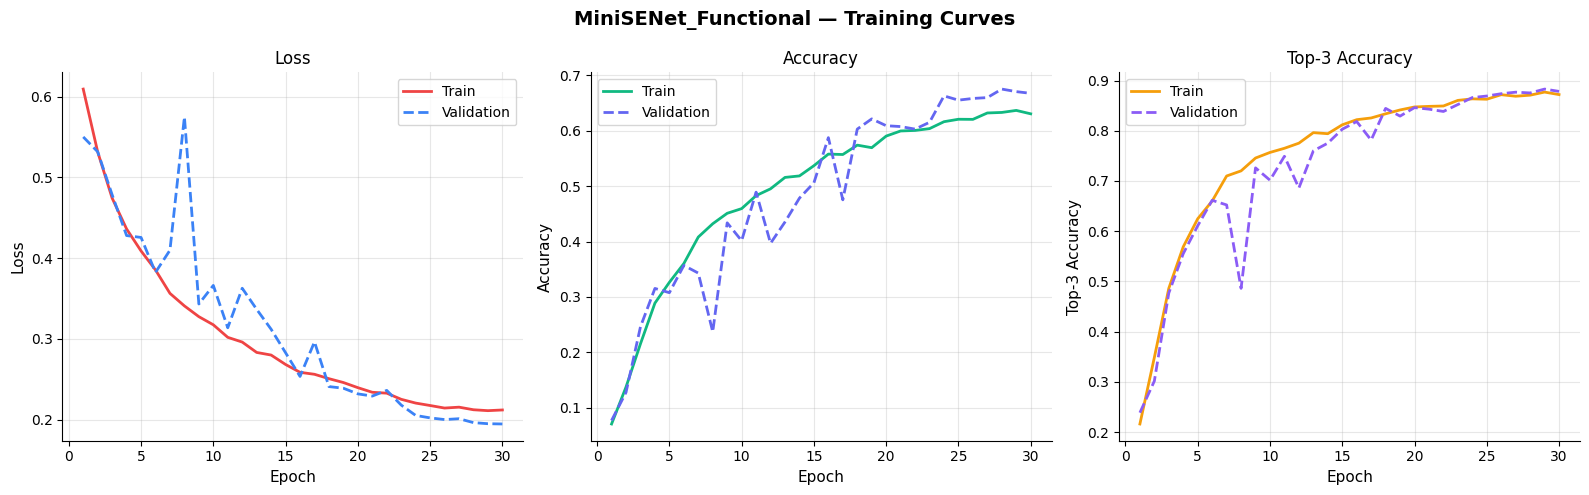

Gambar disimpan → training_curves.png


In [19]:
def plot_training_curves(history, title='Training Curves'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    metrics_to_plot = [
        ('loss',          'Loss',         '#EF4444', '#3B82F6'),
        ('accuracy',      'Accuracy',     '#10B981', '#6366F1'),
        ('top3_accuracy', 'Top-3 Accuracy','#F59E0B', '#8B5CF6'),
    ]

    for ax, (metric, ylabel, c_train, c_val) in zip(axes, metrics_to_plot):
        if metric not in history.history: continue
        epochs = range(1, len(history.history[metric]) + 1)

        ax.plot(epochs, history.history[metric],
                color=c_train, linewidth=2, label='Train')
        val_key = f'val_{metric}'
        if val_key in history.history:
            ax.plot(epochs, history.history[val_key],
                    color=c_val, linewidth=2, linestyle='--', label='Validation')

        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{ylabel}', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gambar disimpan → training_curves.png')


plot_training_curves(history, title=f'{model.name} — Training Curves')

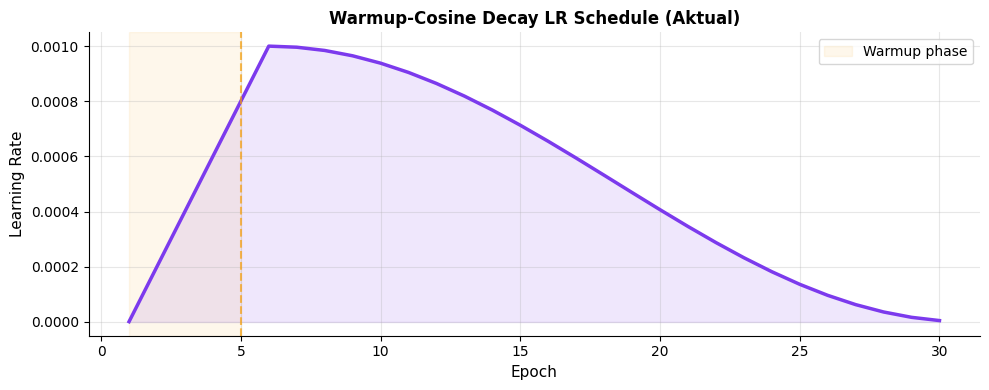

In [20]:
def plot_lr_schedule(lr_history):
    warmup_ep = 5
    fig, ax = plt.subplots(figsize=(10, 4))
    epochs   = range(1, len(lr_history) + 1)

    ax.plot(epochs, lr_history, color='#7C3AED', linewidth=2.5)
    ax.fill_between(epochs, lr_history, alpha=0.12, color='#7C3AED')
    ax.axvspan(1, min(warmup_ep, len(lr_history)), alpha=0.08,
               color='#F59E0B', label='Warmup phase')
    ax.axvline(x=warmup_ep, color='#F59E0B', linestyle='--', alpha=0.7)

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Learning Rate', fontsize=11)
    ax.set_title('Warmup-Cosine Decay LR Schedule (Aktual)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()


plot_lr_schedule(lr_scheduler.lr_history)

# **Test Model**

In [21]:
# Prediksi seluruh test set
print('Prediksi test set...')
y_pred_proba = model.predict(test_ds, verbose=1)
y_pred_raw   = np.argmax(y_pred_proba, axis=1)

print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test_raw, y_pred_raw, target_names=CLASSES))

Prediksi test set...
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Ayam Goreng       0.68      0.64      0.66        50
      Burger       0.82      0.80      0.81        50
French Fries       0.86      0.88      0.87        50
   Gado-Gado       0.57      0.64      0.60        50
 Ikan Goreng       0.60      0.60      0.60        50
  Mie Goreng       0.57      0.52      0.54        50
 Nasi Goreng       0.62      0.56      0.59        50
 Nasi Padang       0.54      0.58      0.56        50
       Pizza       0.76      0.78      0.77        50
       Rawon       0.66      0.80      0.72        50
     Rendang       0.65      0.64      0.65        50
        Sate       0.54      0.44      0.48        50
        Soto       0.80      0.80      0.80        50

    accuracy                           0.67       650
   macro avg       0.67      0.67      0.67       650
weighted avg       0.67      0.67      0.67      

# **Custom Training**

In [22]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

## Eager Mode

In [23]:
def train_step(images, labels):
  with tf.GradientTape() as tape:
    predictions = model(images, training=True)
    loss = loss_object(labels, predictions)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  train_loss_metric.update_state(loss)
  train_accuracy_metric.update_state(labels, predictions)

def val_step(images, labels):
  predictions = model(images, training=False)
  val_accuracy_metric.update_state(labels, predictions)

In [28]:
def train_model(model, train_ds, val_ds, epochs=10):
  for epoch in range(epochs):
    start = time.time()
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Reset metrics di awal setiap epoch
    train_loss_metric.reset_state()
    train_accuracy_metric.reset_state()
    val_accuracy_metric.reset_state()

    for images, labels in train_ds:
      train_step(images, labels)

    for val_images, val_labels in val_ds:
      val_step(val_images, val_labels)

    print(
        f"Train Accuracy: {train_accuracy_metric.result() * 100:.2f}%, ",
        f"Val Accuracy: {val_accuracy_metric.result() * 100:.2f}%",
        f"({time.time() - start:.2f}s)")

In [27]:
model = MyModel()
train_model(model, train_ds, val_ds)

NameError: name 'MyModel' is not defined

## Graph Mode

In [29]:
@tf.function
def train_step(images, labels):
  with tf.GradientTape() as tape:
    predictions = model(images, training=True)
    loss = loss_object(labels, predictions)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  train_loss_metric.update_state(loss)
  train_accuracy_metric.update_state(labels, predictions)

@tf.function
def val_step(images, labels):
  predictions = model(images, training=False)
  val_accuracy_metric.update_state(labels, predictions)

In [30]:
def train_model(model, train_ds, val_ds, epochs=10):
  for epoch in range(epochs):
    start = time.time()
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Reset metrics di awal setiap epoch
    train_loss_metric.reset_state()
    train_accuracy_metric.reset_state()
    val_accuracy_metric.reset_state()

    for images, labels in train_ds:
      train_step(images, labels)

    for val_images, val_labels in val_ds:
      val_step(val_images, val_labels)

    print(
        f"Train Accuracy: {train_accuracy_metric.result() * 100:.2f}%, ",
        f"Val Accuracy: {val_accuracy_metric.result() * 100:.2f}%",
        f"({time.time() - start:.2f}s)")

In [31]:
model = MyModel()
train_model(model, train_ds, val_ds)

NameError: name 'MyModel' is not defined